# ENSAMBLE MODELOS LIGHTGBM Y TABNET
En base a las pruebas realizadas con ambos modelos y que fueron ya desarrolladas en el apartado correspondiente de cada código se efectuó un ensamble de ambos modelos para intentar mejorar el kappa obtenido.

Se importan las librerías y los archivos

In [9]:
# Se importan las librerias a utilizar 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, StratifiedKFold 
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score
from sklearn.utils import shuffle 
import torch
import lightgbm as lgb
import lightgbm as lgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.impute import SimpleImputer
from functools import partial
from scipy.optimize import minimize
from sklearn.metrics import confusion_matrix

# Se importan los archivos para formar los dataset 
breed_df = pd.read_csv(os.path.join(r"C:\Users\jmolina\Downloads\Excelente\breed_labels.csv"))
color_df = pd.read_csv(os.path.join(r"C:\Users\jmolina\Downloads\Excelente\color_labels.csv"))
state_df = pd.read_csv(os.path.join(r"C:\Users\jmolina\Downloads\Excelente\state_labels.csv"))
ruta_archivo = r"C:\Users\jmolina\Downloads\Excelente\df_train_FE_split.csv"
df_train = pd.read_csv(ruta_archivo, sep=',', encoding='latin-1')

Se importa el dataset de test

In [10]:
ruta_archivo = r"C:\Users\jmolina\Downloads\Excelente\df_test_FE_split.csv"
df_test = pd.read_csv(ruta_archivo, sep=',', encoding='latin-1')

Se cambia la columna de tamaño de text a numérico para mejorar la interpretación.

In [11]:
# Se define el diccionario para aplicar el cambio a numeros
mapeo_tamaños = {
    'PequeÃ±o': 1,
    'Mediano': 2,
    'Grande': 3
}

# Se aplica el cambio
df_train['SizeCategory'] = df_train['SizeCategory'].map(mapeo_tamaños)
df_test['SizeCategory'] = df_test['SizeCategory'].map(mapeo_tamaños)

# ADAPTACIONES DATASET LIGHTGBM
Se ajusta el dataset con las variables que no queremos que considere, se fijan los parametros óptimos de acuerdo al optuna hecho en el código original. Esto permite obtener el OOF_LGB que servirá para el ensamble con el otro modeo y las predicciones de test para generar la matríz de confusión final.

In [12]:
# Se define el X e y
# ---------------------------------------------------------
features_to_drop = ['AdoptionSpeed', 'PetID', 'Description']

X = df_train.drop(columns=features_to_drop, errors='ignore').values
y = df_train['AdoptionSpeed'].values

# Para asegurarnos que el df_test ya esté limpio y procesado igual que df_train
X_test = df_test.drop(columns=features_to_drop, errors='ignore').values
y_test = df_test['AdoptionSpeed'].values

# GENERACIÓN DE OOF_LGB Y PREDICCIONES DE TEST
lgb_params = {
    'objective': 'regression',      
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.09586323376644908,
    'num_leaves': 77,
    'min_child_samples': 300,
    'lambda_l1': 2.2512173224589307,
    'lambda_l2': 1.1077927131926015,
    'random_state': 42
}

# Se inicializan los vectores
oof_lgb = np.zeros(len(X))
preds_test_lgb = np.zeros(len(X_test)) # Se guardan las predicciones de test

# Se arma el esquema de validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Iniciando generación de OOF y Predicciones de Test para LightGBM...")

for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X[trn_idx], y[trn_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    
    weights_tr = compute_sample_weight('balanced', y_tr)

    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=weights_tr)
    dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model_lgb = lgb.train(
        lgb_params, 
        dtrain, 
        num_boost_round=2000, 
        valid_sets=[dval], 
        callbacks=[
            lgb.early_stopping(100), 
            lgb.log_evaluation(0) 
        ]
    )
    
    # Guardar predicciones de Validación (OOF)
    oof_lgb[val_idx] = model_lgb.predict(X_val)
    
    # Se agrega para predecir sobre el set el Test, dividimos en 5 (n_splits) para que al terminar el bucle obtengamos el promedio
    preds_test_lgb += model_lgb.predict(X_test) / 5
    
    fold_kappa = cohen_kappa_score(y_val, np.round(np.clip(oof_lgb[val_idx], 0, 4)), weights='quadratic')
    print(f"Fold {fold+1} completado. Kappa (redondeo simple): {fold_kappa:.4f}")

print("\nGeneración de oof_lgb y preds_test_lgb finalizada con éxito.")

Iniciando generación de OOF y Predicciones de Test para LightGBM...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[236]	valid_0's rmse: 1.11918
Fold 1 completado. Kappa (redondeo simple): 0.3320
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[835]	valid_0's rmse: 1.11918
Fold 2 completado. Kappa (redondeo simple): 0.3383
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[971]	valid_0's rmse: 1.10143
Fold 3 completado. Kappa (redondeo simple): 0.3562
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[451]	valid_0's rmse: 1.11289
Fold 4 completado. Kappa (redondeo simple): 0.3395
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1074]	valid_0's rmse: 1.1094
Fold 5 completado. Kappa (redondeo simple): 0.3486

Generación de oof_lgb y preds_test_lgb fi

# ADAPTACIONES DATASET TABNET
Se eliminan las columnas que no se utlizan y tal como fue menionado se cambian las columnas de texto a categóricas y se eliminan los na tanto de las columnas categóricas como de las numéricas.

In [13]:
#Se define qué columnas NO queremos que el modelo vea (IDs y texto libre)
drop_cols = ['AdoptionSpeed', 'PetID', 'Name', 'RescuerID', 'Description', 'BreedID']
features = [c for c in df_train.columns if c not in drop_cols]

# Se identifican las columnas que son texto (object) para transformarlas
categorical_cols = df_train[features].select_dtypes(include=['object', 'category']).columns.tolist()

cat_idxs = []
cat_dims = []

for idx, col in enumerate(features):
    if col in categorical_cols:
        # Aseguramos que no haya nulos y convertimos a string antes de codificar
        df_train[col] = df_train[col].fillna("None").astype(str)
        
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        
        cat_idxs.append(idx)
        cat_dims.append(len(le.classes_))
    else:
        # Como las redes neuronales no aceptan Nans nos aseguramos de que no tengan 
        df_train[col] = df_train[col].fillna(0)

# Verificación final para ver si siguen existiendo columnas que no son numeros
print("Columnas que NO son números:", df_train[features].select_dtypes(exclude=[np.number]).columns.tolist())

Columnas que NO son números: []


# GENERAMOS OOF_TABNET
En base a los hiperparámetros optimos obtenidos en el modelo original se genera el archivo oof para el ensamble y el test para la matriz de confusión. Al igual que el original tiene un balanceo de pesos y la estratificación de los folds de entrenamiento y test

In [14]:
# ---------------------------------------------------------
# GENERACIÓN DE OOF_TABNET CON PARÁMETROS OPTIMIZADOS
# ---------------------------------------------------------

# Se definir los parámetros de arquitectura que obtuvimos
tabnet_params = {
    'n_d': 62,
    'n_a': 62,
    'n_steps': 10,
    'gamma': 1.0339877569002782,
    'lambda_sparse': 1.3380508602088903e-05,
    'cat_idxs': cat_idxs,
    'cat_dims': cat_dims,
    'cat_emb_dim': 1,
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': dict(lr=2e-2),
    'scheduler_params': {"step_size": 10, "gamma": 0.9},
    'scheduler_fn': torch.optim.lr_scheduler.StepLR,
    'mask_type': 'entmax',
    'verbose': 0
}

# Se inician los vectores para OOF y Test
oof_tabnet = np.zeros(len(df_train))
preds_test_tabnet = np.zeros(len(X_test))  # Para acumular predicciones de Test para usar la matriz de confusión

# Asegurar que X y X_test sean arrays de NumPy sin nulos para TabNet
imputer = SimpleImputer(strategy='most_frequent')
X_clean = imputer.fit_transform(X)
X_test_clean = imputer.transform(X_test)  # Para acumular predicciones de Test para usar la matriz de confusión

# Esquema para validación cruzada 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Iniciando generación de OOF para TabNet...")

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_clean, y)):
    X_tr, y_tr = X_clean[trn_idx], y[trn_idx]
    X_val, y_val = X_clean[val_idx], y[val_idx]
    
    # Pesos balanceados
    weights_tr = compute_sample_weight('balanced', y_tr)

    # Inicializar Regresor
    model_tn = TabNetRegressor(**tabnet_params)

    # Entrenar
    model_tn.fit(
        X_train=X_tr, 
        y_train=y_tr.reshape(-1, 1),
        eval_set=[(X_val, y_val.reshape(-1, 1))],
        eval_metric=['rmse'],
        max_epochs=200,
        patience=25,
        batch_size=1024, 
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False,
        weights=weights_tr
    )
    
    # Guardar predicciones continuas de validación
    oof_tabnet[val_idx] = model_tn.predict(X_val).flatten()
    
    # Predecir Test con el modelo de este Fold y sumarlo al promedio
    fold_preds_test = model_tn.predict(X_test_clean).flatten()
    preds_test_tabnet += fold_preds_test / skf.n_splits
    
    # Control rápido
    fold_kappa = cohen_kappa_score(y_val, np.round(np.clip(oof_tabnet[val_idx], 0, 4)), weights='quadratic')
    print(f"Fold {fold+1} completado. Kappa (redondeo simple): {fold_kappa:.4f}")

print("\nGeneración de oof_tabnet y preds_test_tabnet finalizada.")

Iniciando generación de OOF para TabNet...

Early stopping occurred at epoch 80 with best_epoch = 55 and best_val_0_rmse = 1.14052


c:\Users\jmolina\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold 1 completado. Kappa (redondeo simple): 0.3058

Early stopping occurred at epoch 64 with best_epoch = 39 and best_val_0_rmse = 1.17043


c:\Users\jmolina\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold 2 completado. Kappa (redondeo simple): 0.2448

Early stopping occurred at epoch 42 with best_epoch = 17 and best_val_0_rmse = 1.15441


...

Fold 3 completado. Kappa (redondeo simple): 0.2152

Early stopping occurred at epoch 95 with best_epoch = 70 and best_val_0_rmse = 1.14915


c:\Users\jmolina\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold 4 completado. Kappa (redondeo simple): 0.2755

Early stopping occurred at epoch 50 with best_epoch = 25 and best_val_0_rmse = 1.15979


c:\Users\jmolina\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold 5 completado. Kappa (redondeo simple): 0.2135

Generación de oof_tabnet y preds_test_tabnet finalizada.


# DEFINICIÓN DE UMBRALES OPTIMOS Y ENSAMBLE
En base al otimizedrounder que fue explicado en tabnet se ajustan los umbrales de corte para que capturen de la mejor forma posible los valores reales de las clases.

Por último se hace el ensamble como un promedio simple de los out of fold posible teniendo en cuenta la similitud de los resultados se le asigna a cada caso individual una de las clases, optimizando primero los umbrales de corte, dejamos constancia del kappa conjunto y los umbrales de corte identificados.

In [ ]:
# =========================================================================
# DEFINICIÓN DE OPTIMIZED ROUNDER (Algoritmo de optimización de umbrales)
# =========================================================================
class OptimizedRounder(object):
    def __init__(self):
        self.coef_ = 0
    
    def _kappa_loss(self, coef, X, y):
        """Función objetivo que Scipy intentará minimizar (Kappa negativo)"""
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred < coef[1]:
                X_p[i] = 1
            elif pred < coef[2]:
                X_p[i] = 2
            elif pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        
        ll = cohen_kappa_score(y, X_p, weights='quadratic')
        return -ll # Negativo porque 'minimize' busca el mínimo absoluto
    
    def fit(self, X, y):
        """Busca las fronteras óptimas usando el método Nelder-Mead"""
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        initial_coef = [1.0559, 1.9283, 2.4331, 2.6430]
        self.coef_ = minimize(loss_partial, initial_coef, method='nelder-mead')
        
    def predict(self, X, coef=None):
        """Mapea las predicciones continuas a clases (0, 1, 2, 3, 4) usando los umbrales"""
        if coef is None:
            coef = self.coef_['x'] # Extrae los umbrales optimizados por scipy
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred < coef[1]:
                X_p[i] = 1
            elif pred < coef[2]:
                X_p[i] = 2
            elif pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        return X_p.astype(int)

# ---------------------------------------------------------
# 6. ENSAMBLE Y RESULTADOS
# ---------------------------------------------------------

# Promedio simple de tus vectores Out-of-Fold continuos
oof_ensemble = (oof_lgb + oof_tabnet) / 2

# Inicializar y ajustar el optimizador de cortes
rounder = OptimizedRounder()
rounder.fit(oof_ensemble, y)

# Transformar las predicciones decimales en enteros óptimos (0 a 4)
final_preds = rounder.predict(oof_ensemble)

print("\n" + "="*30)
print(f"KAPPA ENSAMBLE FINAL: {cohen_kappa_score(y, final_preds, weights='quadratic'):.4f}")
# Modificado a rounder.coef_['x'] para ver sólo la lista con los 4 números de corte
print(f"Umbrales óptimos: {rounder.coef_['x']}")
print("="*30)


KAPPA ENSAMBLE FINAL: 0.3955
Umbrales óptimos: [1.0910271  1.89613115 2.36053511 2.8105123 ]


# MATRIZ DE CONFUSIÓN
Para evaluar la eficacia del modelo creamos la matriz de confusión.

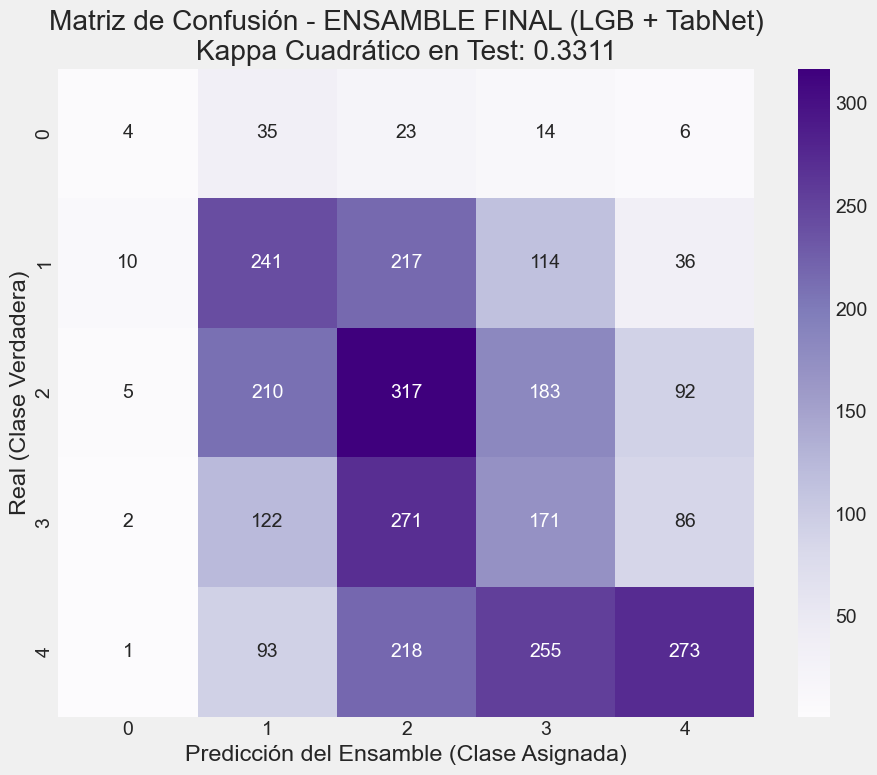

In [ ]:
# Se generar predicciones del ensamble en test
preds_test_ensemble = (preds_test_lgb + preds_test_tabnet) / 2

# Se aplican los umbrales optimos del rounder previamente ajustado con los datos OOF
final_test_preds = rounder.predict(preds_test_ensemble)

# Se calcula el score kappa en test
kappa_test = cohen_kappa_score(y_test, final_test_preds, weights='quadratic')

# Se calcula la matriz de confusión del ensamble
cm_ensemble = confusion_matrix(y_test, final_test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['0', '1', '2', '3', '4'], 
            yticklabels=['0', '1', '2', '3', '4'])

plt.xlabel('Predicción del Ensamble (Clase Asignada)')
plt.ylabel('Real (Clase Verdadera)')
plt.title(f'Matriz de Confusión - ENSAMBLE FINAL (LGB + TabNet)\nKappa Cuadrático en Test: {kappa_test:.4f}')
plt.show()